In [ ]:
from dateutil import parser
import pandas as pd
import matplotlib.pyplot as plt

def parse_dates(df):
    df = df.copy()

    def safe_parse(x):
        if pd.isna(x):
            return pd.NaT
        try:
            return parser.parse(str(x), fuzzy=True)
        except Exception:
            return pd.NaT

    df["timestamp"] = df["date"].apply(safe_parse)
    return df



In [44]:
# Load the DataFrames from the CSV files
arnold_inbox_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/arnold_inbox.csv")
arnold_sent_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/arnold_sent.csv")
arnold_inbox_entities_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/arnold_inbox_entities.csv")
arnold_sent_entities_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/arnold_sent_entities.csv")

benson_inbox_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/benson_inbox.csv")
benson_sent_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/benson_sent.csv")
benson_inbox_entities_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/benson_inbox_entities.csv")
benson_sent_entities_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/benson_sent_entities.csv")   

scott_inbox_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/scott_inbox.csv")
scott_sent_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/scott_sent.csv")
scott_inbox_entities_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/scott_inbox_entities.csv")
scott_sent_entities_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/scott_sent_entities.csv") 

lavorato_inbox_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/lavorato_inbox.csv")
lavorato_sent_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/lavorato_sent.csv")
lavorato_inbox_entities_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/lavorato_inbox_entities.csv") 
lavorato_sent_entities_df = pd.read_csv("/Users/leuphi/OneDrive/Philipp/ComputerScience/NLP/data/out/lavorato_sent_entities.csv")   



arnold_inbox_df = parse_dates(arnold_inbox_df)
arnold_sent_df = parse_dates(arnold_sent_df)
benson_inbox_df = parse_dates(benson_inbox_df)
benson_sent_df = parse_dates(benson_sent_df)
scott_inbox_df = parse_dates(scott_inbox_df)
scott_sent_df = parse_dates(scott_sent_df)
lavorato_inbox_df = parse_dates(lavorato_inbox_df)
lavorato_sent_df = parse_dates(lavorato_sent_df)





In [45]:
def build_timeline(df):
    df = df.copy()
    df = df.dropna(subset=["timestamp"])
    df["date_only"] = df["timestamp"].dt.date
    timeline = df.groupby("date_only").size().reset_index(name="email_count")
    return timeline



arnold_inbox_df["timestamp"] = pd.to_datetime( arnold_inbox_df["timestamp"], errors="coerce" )
arnold_sent_df["timestamp"] = pd.to_datetime( arnold_sent_df["timestamp"], errors="coerce" )
benson_inbox_df["timestamp"] = pd.to_datetime( benson_inbox_df["timestamp"], errors="coerce" )
benson_sent_df["timestamp"] = pd.to_datetime( benson_sent_df["timestamp"], errors="coerce" )
scott_inbox_df["timestamp"] = pd.to_datetime( scott_inbox_df["timestamp"], errors="coerce" )        
scott_sent_df["timestamp"] = pd.to_datetime( scott_sent_df["timestamp"], errors="coerce" )
lavorato_inbox_df["timestamp"] = pd.to_datetime( lavorato_inbox_df["timestamp"], errors="coerce" )
lavorato_sent_df["timestamp"] = pd.to_datetime( lavorato_sent_df["timestamp"], errors="coerce" )

arnold_inbox_timeline = build_timeline(arnold_inbox_df)
arnold_sent_timeline = build_timeline(arnold_sent_df)
benson_inbox_timeline = build_timeline(benson_inbox_df)
benson_sent_timeline = build_timeline(benson_sent_df)
scott_inbox_timeline = build_timeline(scott_inbox_df)
scott_sent_timeline = build_timeline(scott_sent_df)
lavorato_inbox_timeline = build_timeline(lavorato_inbox_df)
lavorato_sent_timeline = build_timeline(lavorato_sent_df)


In [46]:
def timeline_for_keyword(df, keyword):
    df = df.copy()
    df = df.dropna(subset=["timestamp"])

    # Keyword-Filter (case-insensitive)
    df_kw = df[df["body"].str.contains(keyword, case=False, na=False)]

    # Datum extrahieren
    df_kw["date_only"] = df_kw["timestamp"].dt.date

    # Aggregation
    timeline = df_kw.groupby("date_only").size().reset_index(name="count")

    return timeline


def plot_keyword_timeline(df, keyword):
    timeline = timeline_for_keyword(df, keyword)

    plt.figure(figsize=(12, 5))
    plt.plot(timeline["date_only"], timeline["count"], marker="o")
    plt.title(f"Timeline für Keyword: '{keyword}'")
    plt.xlabel("Datum")
    plt.ylabel("Anzahl Erwähnungen")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


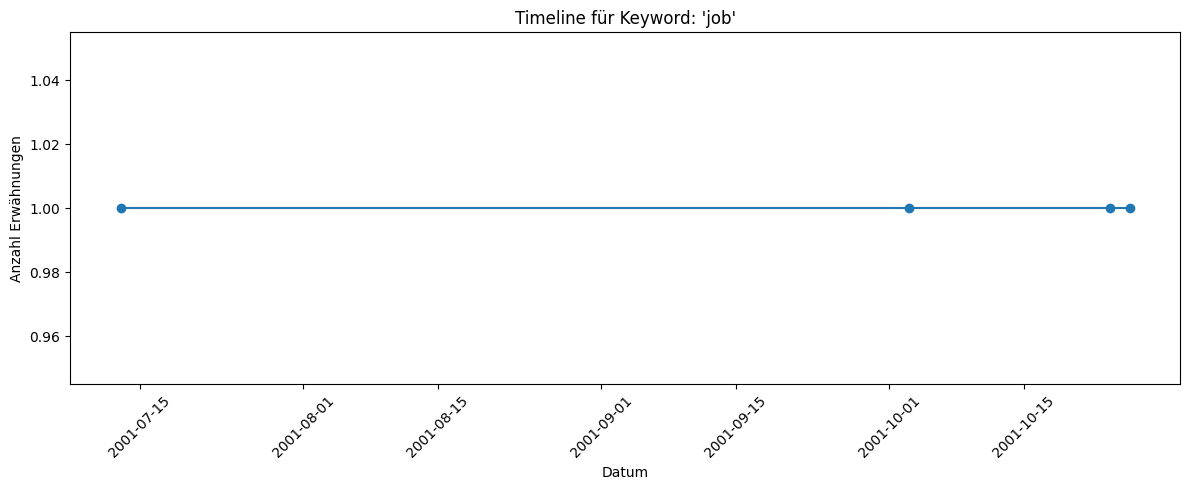

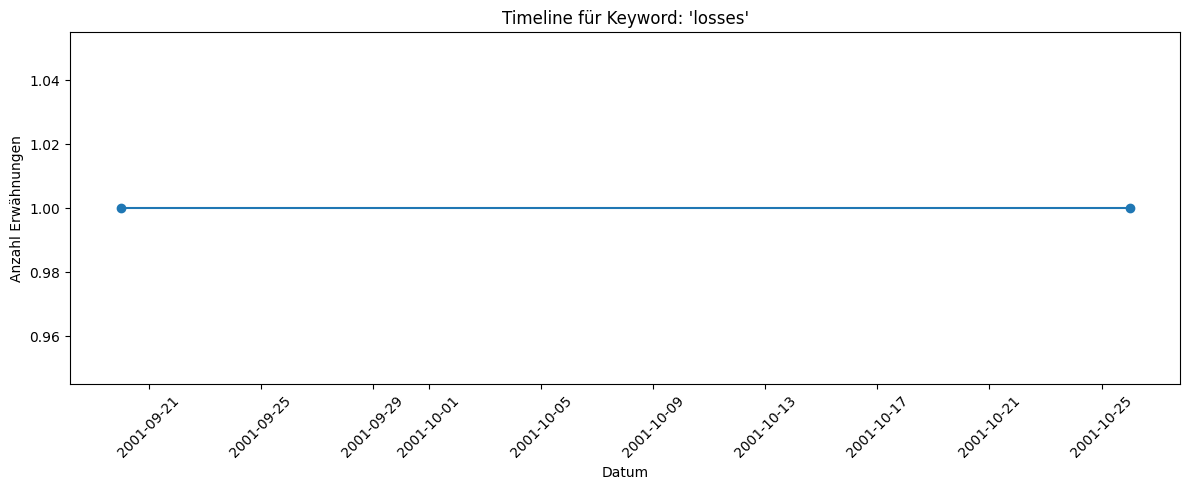

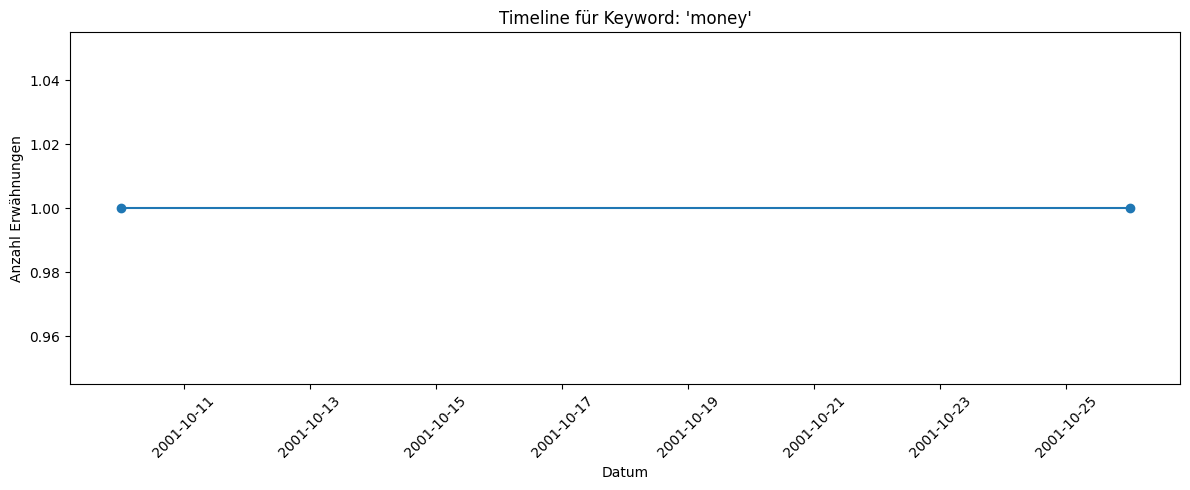

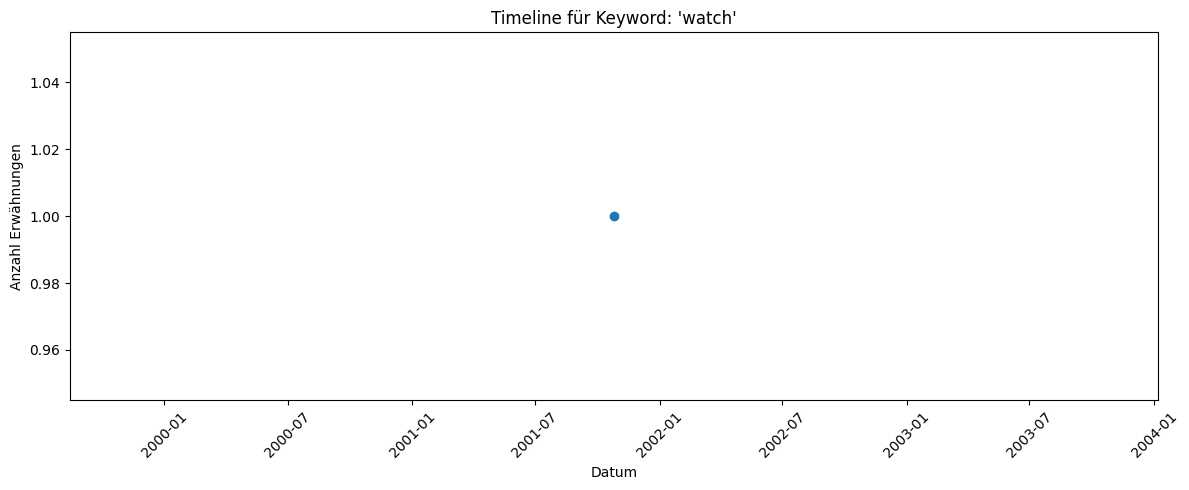

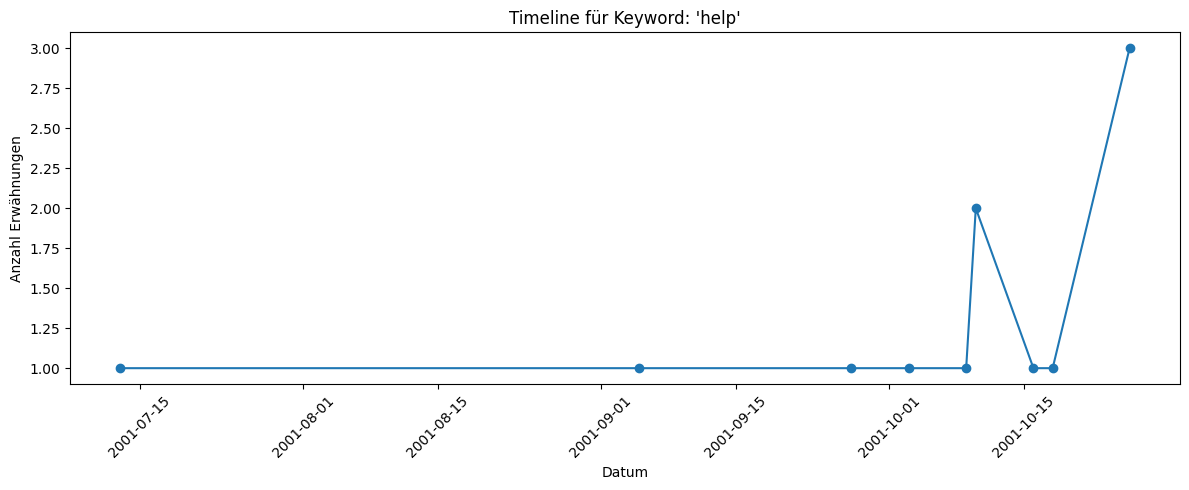

In [39]:
plot_keyword_timeline(arnold_inbox_df, "job")
plot_keyword_timeline(arnold_inbox_df, "losses")
plot_keyword_timeline(arnold_inbox_df, "money")
plot_keyword_timeline(arnold_inbox_df, "watch")
plot_keyword_timeline(arnold_inbox_df, "help")


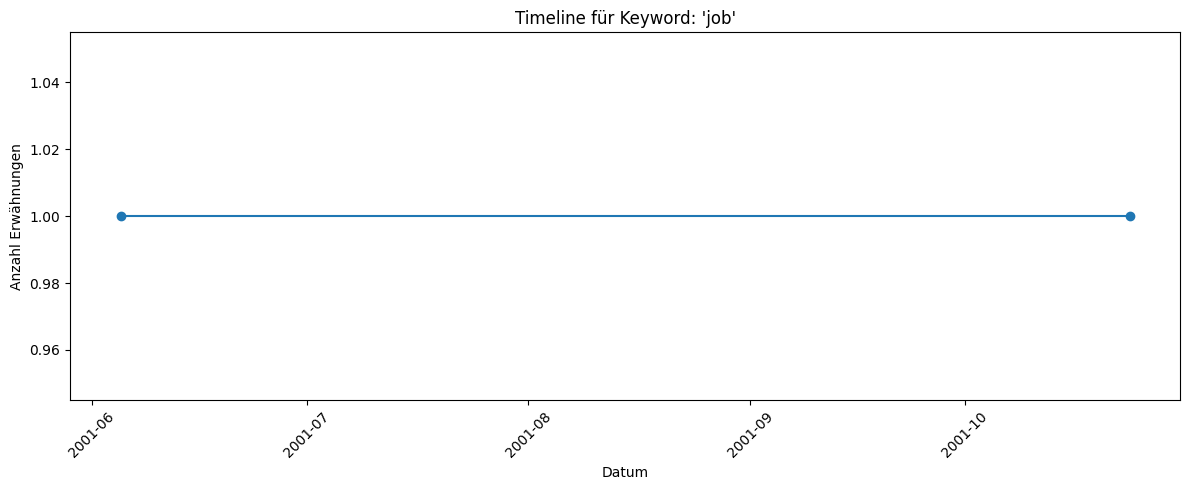

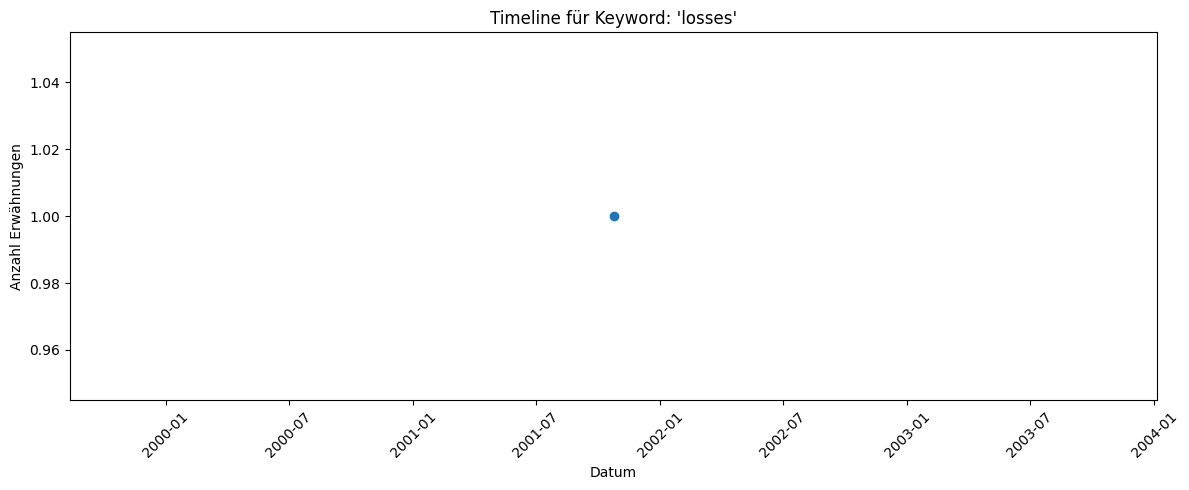

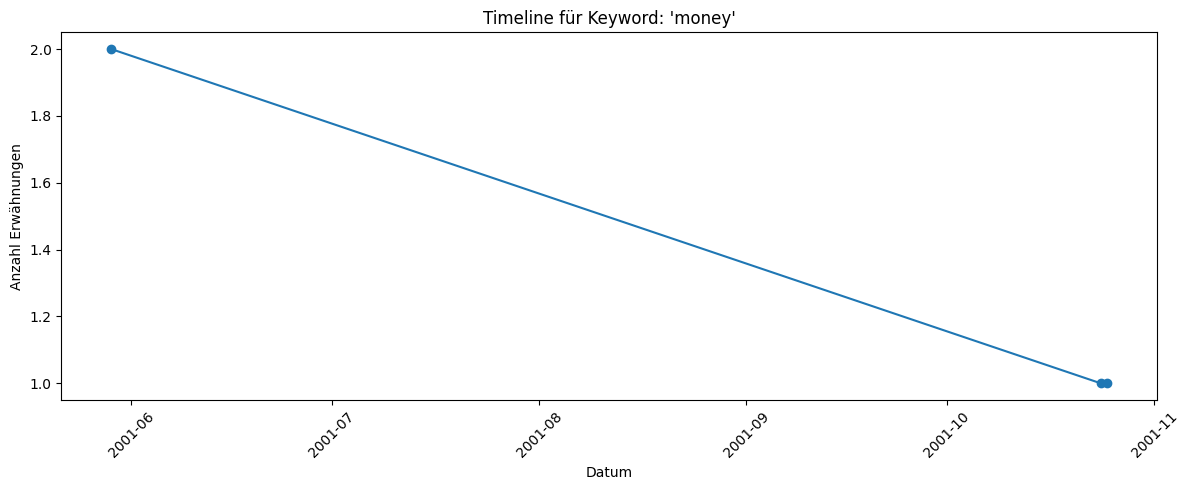

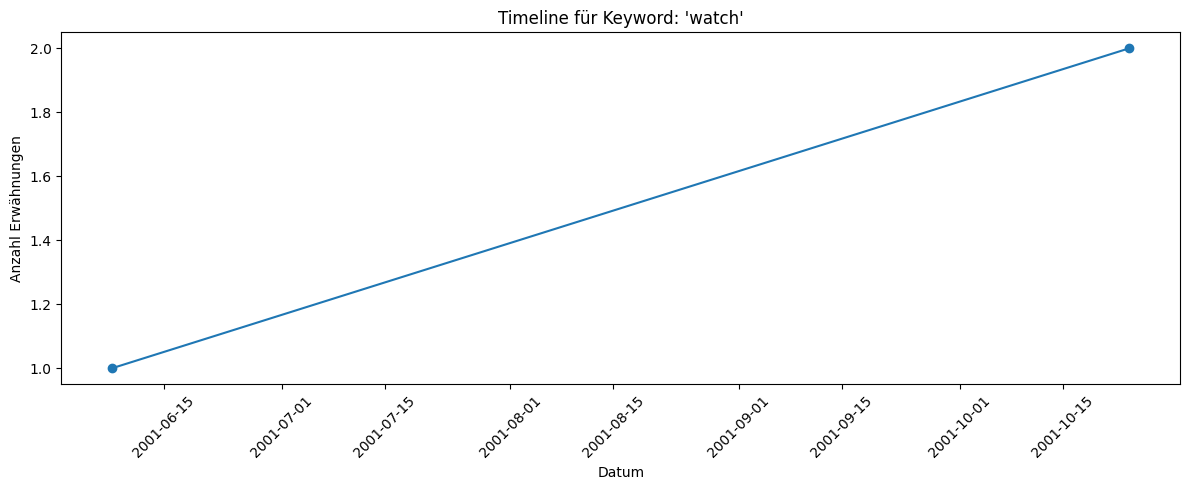

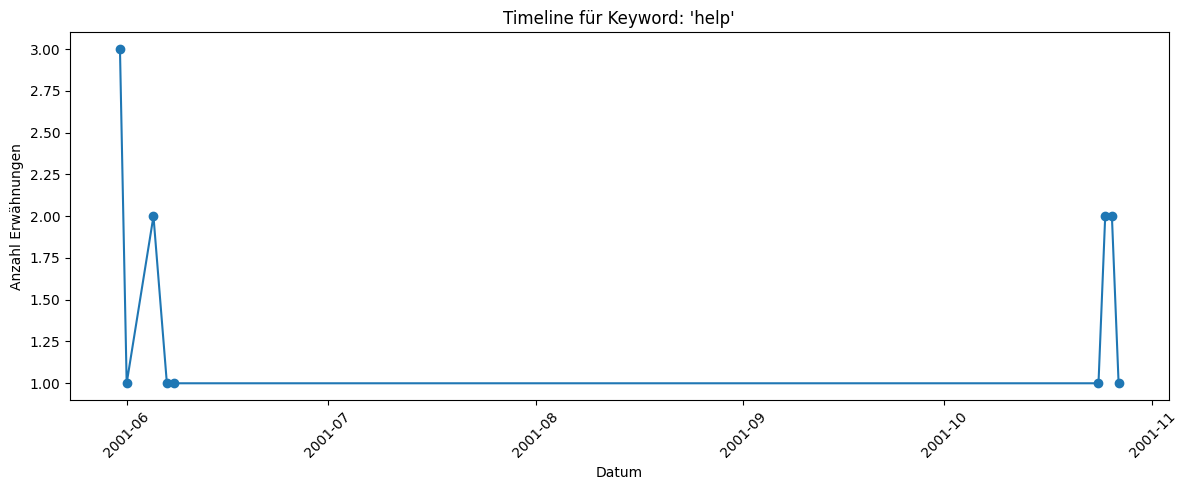

In [41]:
plot_keyword_timeline(lavorato_inbox_df, "job")
plot_keyword_timeline(lavorato_inbox_df, "losses")
plot_keyword_timeline(lavorato_inbox_df, "money")
plot_keyword_timeline(lavorato_inbox_df, "watch")
plot_keyword_timeline(lavorato_inbox_df, "help")

Perform Entity based Timeline analysis

In [47]:
def merge_entities_with_emails(df_emails, df_entities):
    return df_entities.merge(
        df_emails[["file", "timestamp"]],
        left_on="email_id",
        right_on="file",
        how="left"
    )

lavorato_inbox_entities_merged = merge_entities_with_emails(lavorato_inbox_df, lavorato_inbox_entities_df)

Here we want to run it for a particular person:

In [ ]:
def timeline_for_person(df_entities, person_name):
    df = df_entities.copy()
    df = df.dropna(subset=["timestamp"])

    # Filter auf Person
    df_person = df[
        (df["type"] == "PERSON") &
        (df["entity_clean"].str.contains(person_name.upper(), na=False))
    ]

    df_person["date_only"] = df_person["timestamp"].dt.date

    timeline = df_person.groupby("date_only").size().reset_index(name="count")

    return timeline



In [49]:
def plot_person_timeline(df_entities, person_name):
    timeline = timeline_for_person(df_entities, person_name)

    plt.figure(figsize=(12, 5))
    plt.plot(timeline["date_only"], timeline["count"], marker="o")
    plt.title(f"Timeline für Person: {person_name}")
    plt.xlabel("Datum")
    plt.ylabel("Anzahl Erwähnungen")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


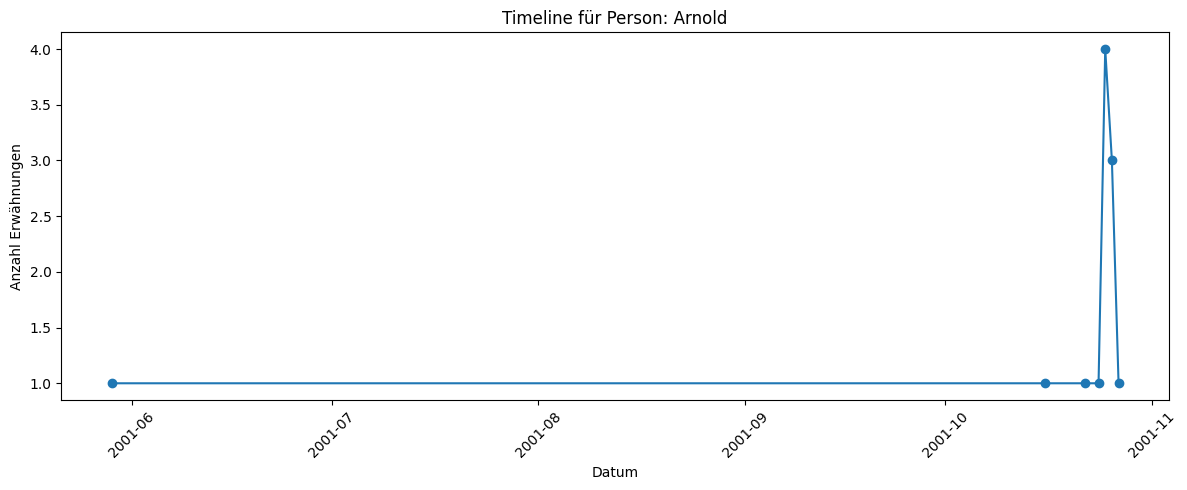

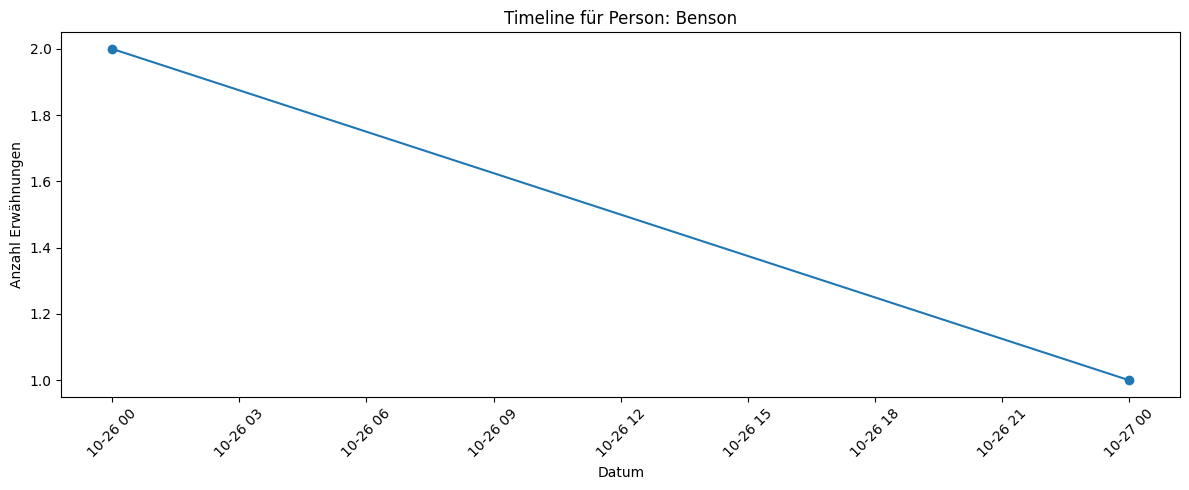

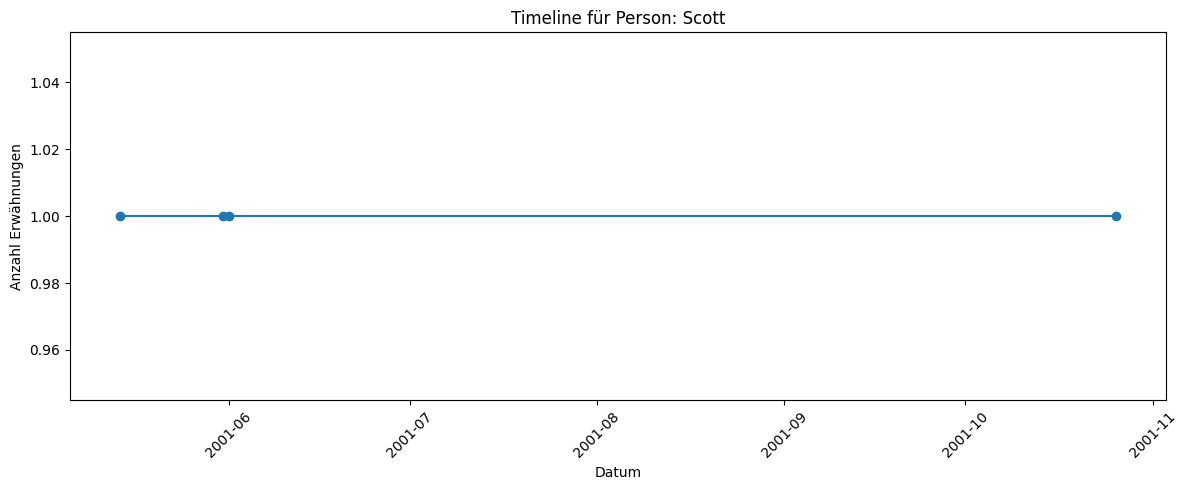

In [50]:
plot_person_timeline(lavorato_inbox_entities_merged, "Arnold")
plot_person_timeline(lavorato_inbox_entities_merged, "Benson")
plot_person_timeline(lavorato_inbox_entities_merged, "Scott")
